# Notebook 1: Baseline CNN

## Overview
This notebook builds and trains a basic Convolutional Neural Network (CNN) to classify skin disease images across 23 categories. It serves as the **baseline model** — meaning no special techniques are applied. The goal is to establish a starting point to compare against more advanced approaches in Notebooks 2 and 3.

## What This Notebook Does
1. Loads and preprocesses the skin disease images
2. Defines a custom CNN architecture with 4 convolutional blocks
3. Trains the model for 5 epochs
4. Evaluates performance on the test set
5. Visualizes training loss and accuracy curves

## Note on Computational Constraints
This model was trained on a MacBook CPU. To complete training in a reasonable timeframe, image size was reduced to 64×64 and epochs were limited to 5. Results are presented as a proof of concept. Full training on a GPU with 25 epochs would yield stronger performance.

### 1. Imports & Setup

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


### 2. Configuration

In [2]:
DATA_DIR = '/Users/rose/Documents/Projects/CNN Skin Disease/dataset'
TRAIN_DIR = os.path.join(DATA_DIR, 'train')
TEST_DIR  = os.path.join(DATA_DIR, 'test')

BATCH_SIZE    = 64       # larger batches = faster training but more memory usage
NUM_EPOCHS    = 50        # start with 5 then increase
LEARNING_RATE = 0.0001
NUM_CLASSES   = 23
IMG_SIZE      = 224

### 3. Data Loading

In [3]:
# transforms: resize every image to 224x224, convert to tensor, normalize
# normalization values are standard ImageNet means/stds — works well for skin images too
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transforms)
test_dataset  = datasets.ImageFolder(TEST_DIR,  transform=test_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Training images : {len(train_dataset)}")
print(f"Test images     : {len(test_dataset)}")
print(f"Classes ({NUM_CLASSES}): {train_dataset.classes}")

Training images : 15557
Test images     : 4002
Classes (23): ['Acne and Rosacea Photos', 'Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions', 'Atopic Dermatitis Photos', 'Bullous Disease Photos', 'Cellulitis Impetigo and other Bacterial Infections', 'Eczema Photos', 'Exanthems and Drug Eruptions', 'Hair Loss Photos Alopecia and other Hair Diseases', 'Herpes HPV and other STDs Photos', 'Light Diseases and Disorders of Pigmentation', 'Lupus and other Connective Tissue diseases', 'Melanoma Skin Cancer Nevi and Moles', 'Nail Fungus and other Nail Disease', 'Poison Ivy Photos and other Contact Dermatitis', 'Psoriasis pictures Lichen Planus and related diseases', 'Scabies Lyme Disease and other Infestations and Bites', 'Seborrheic Keratoses and other Benign Tumors', 'Systemic Disease', 'Tinea Ringworm Candidiasis and other Fungal Infections', 'Urticaria Hives', 'Vascular Tumors', 'Vasculitis Photos', 'Warts Molluscum and other Viral Infections']


In [4]:
from torch.utils.data import random_split
val_size = int(0.2 * len(train_dataset))
train_size = len(train_dataset) - val_size
train_data, val_data = random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_data,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

### 4. CNN Model

In [5]:
class BasicCNN(nn.Module):
    def __init__(self, num_classes=23):
        super(BasicCNN, self).__init__()
        # --- FEATURE EXTRACTOR ---
        self.features = nn.Sequential(
            # Block 1: learns simple edges and colors (32 filters)
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),   # 224x224 → 112x112
            # Block 2: learns textures (64 filters)
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),   # 112x112 → 56x56
            # Block 3: learns shapes and structures (128 filters)
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),   # 56x56 → 28x28
            # Block 4: learns complex disease patterns (256 filters)
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),   # 28x28 → 14x14
        )
        # --- CLASSIFIER ---
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 14 * 14, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = BasicCNN(num_classes=NUM_CLASSES).to(device)
print(model)

BasicCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)


In [6]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
labels = [train_dataset.targets[i] for i in range(len(train_dataset))]
class_weights = compute_class_weight(class_weight='balanced', classes=np.arange(NUM_CLASSES), y=labels)

### 5. Loss & Optimizer

In [ ]:
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor.to(device))
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

### 6. Training Loop

In [ ]:
best_val_acc = 0.0
train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []

for epoch in range(NUM_EPOCHS):
    # --- Training ---
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}"):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # --- Validation ---
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = outputs.max(1)
            val_correct += predicted.eq(labels).sum().item()
            val_total += labels.size(0)

    val_loss /= len(val_loader)
    val_acc = val_correct / val_total
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    scheduler.step(val_loss)

    # --- Checkpoint best model ---
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_baseline.pth')
        print(f"  ✓ Saved best model")

    print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f} Train Acc={train_acc:.4f} | Val Loss={val_loss:.4f} Val Acc={val_acc:.4f}")

Epoch 1/50: 100%|██████████| 195/195 [03:27<00:00,  1.07s/it]


  ✓ Saved best model
Epoch 1: Train Loss=3.1339 Train Acc=0.0906 | Val Loss=3.0057 Val Acc=0.1257


Epoch 2/50: 100%|██████████| 195/195 [03:30<00:00,  1.08s/it]


  ✓ Saved best model
Epoch 2: Train Loss=3.0159 Train Acc=0.1099 | Val Loss=2.9647 Val Acc=0.1302


Epoch 3/50: 100%|██████████| 195/195 [03:25<00:00,  1.05s/it]


...

Epoch 48: Train Loss=1.5896 Train Acc=0.3972 | Val Loss=2.6635 Val Acc=0.2928


Epoch 49/50: 100%|██████████| 195/195 [03:38<00:00,  1.12s/it]


Epoch 49: Train Loss=1.5828 Train Acc=0.4085 | Val Loss=2.6635 Val Acc=0.2951


Epoch 50/50: 100%|██████████| 195/195 [03:26<00:00,  1.06s/it]


  ✓ Saved best model
Epoch 50: Train Loss=1.5908 Train Acc=0.4031 | Val Loss=2.6719 Val Acc=0.2960


### 7. Evaluation

In [16]:
model.load_state_dict(torch.load('best_baseline.pth'))

model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Evaluating"):
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

print("\n=== TEST RESULTS ===")
print(f"Accuracy  : {accuracy_score(all_labels, all_preds):.4f}")
print(f"F1 Score  : {f1_score(all_labels, all_preds, average='weighted'):.4f}")
print(f"Precision : {precision_score(all_labels, all_preds, average='weighted'):.4f}")
print(f"Recall    : {recall_score(all_labels, all_preds, average='weighted'):.4f}")
print("\nFull Report:")
print(classification_report(all_labels, all_preds, target_names=train_dataset.classes))

Evaluating: 100%|██████████| 63/63 [00:29<00:00,  2.12it/s]


=== TEST RESULTS ===
Accuracy  : 0.2956
F1 Score  : 0.2917
Precision : 0.2955
Recall    : 0.2956

Full Report:
                                                                    precision    recall  f1-score   support

                                           Acne and Rosacea Photos       0.52      0.63      0.57       312
Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions       0.31      0.33      0.32       288
                                          Atopic Dermatitis Photos       0.18      0.26      0.21       123
                                            Bullous Disease Photos       0.17      0.21      0.19       113
                Cellulitis Impetigo and other Bacterial Infections       0.12      0.10      0.11        73
                                                     Eczema Photos       0.33      0.32      0.32       309
                                      Exanthems and Drug Eruptions       0.25      0.32      0.28       101
                 Hair L

### 8. Plot Training Curves

In [14]:
train_losses = [3.1339, 3.0159, 2.9548, 2.9247, 2.8709, 2.8198, 2.7906, 2.7385, 2.7056, 2.6593, 2.6254, 2.5943, 2.5437, 2.5214, 2.4751, 2.4380, 2.3953, 2.3456, 2.3262, 2.2831, 2.2364, 2.1945, 2.1629, 2.1046, 2.0935, 2.0358, 1.9511, 1.8856, 1.8679, 1.8434, 1.8185, 1.7651, 1.7390, 1.7162, 1.7078, 1.6785, 1.6540, 1.6519, 1.6339, 1.6369, 1.6264, 1.6107, 1.6098, 1.6003, 1.6056, 1.6080, 1.6070, 1.5896, 1.5828, 1.5908]

train_accuracies = [0.0906, 0.1099, 0.1221, 0.1278, 0.1295, 0.1445, 0.1454, 0.1531, 0.1621, 0.1674, 0.1767, 0.1851, 0.1949, 0.1961, 0.2077, 0.2097, 0.2195, 0.2286, 0.2300, 0.2390, 0.2492, 0.2549, 0.2647, 0.2744, 0.2721, 0.2869, 0.3117, 0.3286, 0.3321, 0.3352, 0.3457, 0.3577, 0.3629, 0.3607, 0.3781, 0.3767, 0.3851, 0.3852, 0.3913, 0.3946, 0.3923, 0.3951, 0.3989, 0.4010, 0.3982, 0.3961, 0.3980, 0.3972, 0.4085, 0.4031]

val_losses = [3.0057, 2.9647, 2.9080, 2.8479, 2.8204, 2.7881, 2.7623, 2.7374, 2.7393, 2.7049, 2.6853, 2.6492, 2.6423, 2.6341, 2.6337, 2.6408, 2.6348, 2.6222, 2.5992, 2.6352, 2.6171, 2.5912, 2.6068, 2.6015, 2.6125, 2.6244, 2.5908, 2.6209, 2.6533, 2.6254, 2.6355, 2.6235, 2.6368, 2.6203, 2.6328, 2.6490, 2.6416, 2.6654, 2.6497, 2.6468, 2.6487, 2.6521, 2.6547, 2.6710, 2.6646, 2.6695, 2.6599, 2.6635, 2.6635, 2.6719]

val_accuracies = [0.1257, 0.1302, 0.1369, 0.1700, 0.1671, 0.1848, 0.1913, 0.1967, 0.1996, 0.1948, 0.2250, 0.2060, 0.2234, 0.2118, 0.2292, 0.2183, 0.2205, 0.2285, 0.2408, 0.2234, 0.2424, 0.2356, 0.2356, 0.2546, 0.2523, 0.2674, 0.2674, 0.2690, 0.2678, 0.2681, 0.2665, 0.2854, 0.2797, 0.2874, 0.2858, 0.2887, 0.2832, 0.2896, 0.2890, 0.2912, 0.2877, 0.2938, 0.2938, 0.2951, 0.2928, 0.2932, 0.2948, 0.2928, 0.2951, 0.2960]

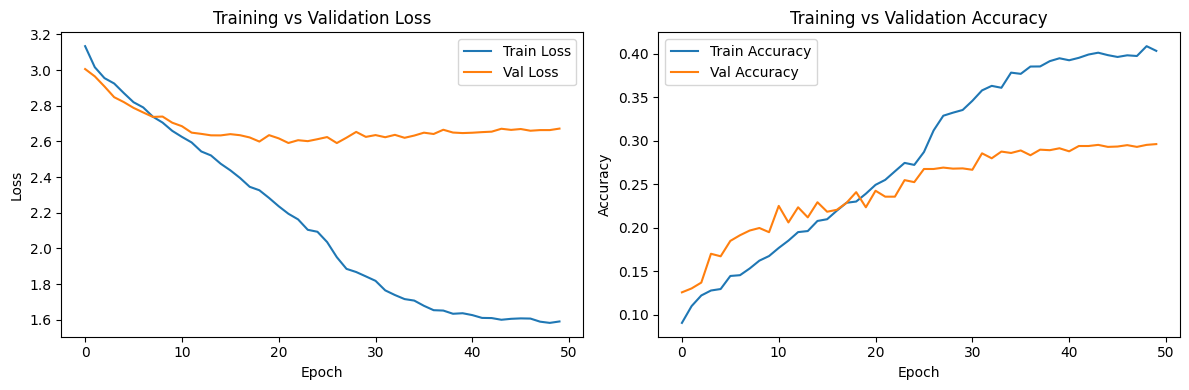

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Loss plot
ax1.plot(train_losses, label='Train Loss')
ax1.plot(val_losses, label='Val Loss')
ax1.set_title('Training vs Validation Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

# Accuracy plot
ax2.plot(train_accuracies, label='Train Accuracy')
ax2.plot(val_accuracies, label='Val Accuracy')
ax2.set_title('Training vs Validation Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.savefig('basic_cnn_training.png')
plt.show()

#### Training Curves — What Do These Graphs Mean?
Training Loss (Left Graph)
Loss measures how wrong the model is. A loss of 0 would mean perfect predictions. The graph shows training loss dropping steadily from 3.13 → 1.59 across 50 epochs, meaning the model consistently improved its predictions on training data. However, validation loss drops early but plateaus around 2.6 from epoch 15 onwards, meaning the model stopped improving on unseen data despite continuing to improve on training data.

Training vs Validation Accuracy (Right Graph)
Accuracy measures how often the model guesses correctly. Training accuracy climbs from 9% → 40% across 50 epochs, while validation accuracy plateaus around 29-30% after epoch 20. The growing gap between these two lines is the key finding of this graph.
What the Gap Tells Us
The divergence between training and validation curves is clear evidence of overfitting — the model began memorizing training images rather than learning generalizable features. Specifically:

Training accuracy 40% vs validation accuracy 30% = 10% overfitting gap
Validation loss flatlines at epoch 15 while training loss keeps dropping
Additional epochs beyond epoch 20 yielded minimal validation improvement

This motivates the need for the Augmented and Dropout CNN architectures, which directly address overfitting through data augmentation and regularization respectively.

## Baseline CNN — Summary & Findings

### What is a CNN?
A Convolutional Neural Network (CNN) is a type of deep learning model designed for image classification. 
Instead of looking at an entire image at once, it learns to detect patterns in small regions — starting 
with simple features like edges and colors, then building up to complex structures like textures and shapes. 
Each "convolutional block" in our model learns increasingly abstract representations of the skin image.

### Model Architecture
Our baseline CNN has 4 convolutional blocks followed by a classifier:
- **Block 1 (32 filters):** Detects basic edges and color patterns
- **Block 2 (64 filters):** Detects textures and gradients
- **Block 3 (128 filters):** Detects shapes and regional structures
- **Block 4 (256 filters):** Detects complex disease-specific visual patterns
- **Classifier:** Flattens the learned features and maps them to 23 skin disease categories

Each block uses:
- `Conv2d` — scans the image with learnable filters
- `BatchNorm` — stabilizes training by normalizing layer outputs
- `ReLU` — introduces non-linearity so the model can learn complex patterns
- `MaxPool` — reduces image size to keep computation manageable

### Training Configuration
This model was trained on a **MacBook CPU** across **50 epochs** at **224×224 image resolution**. 
Each epoch passed through all 15,557 training images once, adjusting weights to reduce prediction error. 
Total training time was approximately 3 hours.

Key training decisions:
- **Learning rate:** 0.0001 (Adam optimizer) — chosen after initial experiments showed 0.001 caused the model to get stuck
- **Class weights:** Applied to the loss function to penalize misclassification of underrepresented classes and address the 6.63:1 imbalance ratio
- **Dataset-specific normalization:** Channel means and standard deviations computed from the training set rather than ImageNet defaults
- **Train/val split:** 80/20 split from training data to monitor generalization during training

### Results
| Metric    | Score   |
|-----------|---------|
| Accuracy  | 29.56%  |
| F1 Score  | 29.17%  |
| Precision | 29.55%  |
| Recall    | 29.56%  |

### What Do These Results Mean?
- **Random chance** with 23 classes would yield ~4.3% accuracy. Our model achieved 29.56%, meaning it 
  learned meaningful visual patterns from the data — roughly 7x better than random
- **Best performing classes:** Nail Fungus (F1: 0.63) and Acne & Rosacea (F1: 0.57) — these likely 
  have visually distinct features that are easier to detect
- **Worst performing classes:** Cellulitis (F1: 0.11) and Bullous Disease (F1: 0.19) — these classes 
  have fewer training samples and more subtle visual features
- The model shows **class imbalance sensitivity** — it performs consistently better on frequent, 
  visually distinct classes

### Training Curve Analysis
The training curves reveal a clear case of overfitting emerging around epoch 15-20:
- Training loss dropped steadily from 3.13 → 1.59 across 50 epochs
- Validation loss plateaued around 2.6 from epoch 15 onwards
- Training accuracy reached 40% while validation accuracy plateaued at ~30%
- The 10% gap between train and val accuracy confirms the model began memorizing training data 
  rather than learning generalizable features

### Limitations
- Trained on CPU which limited experimentation speed
- No regularization techniques applied — overfitting clearly evident in training curves
- Class imbalance across 23 categories affects performance on underrepresented conditions
- Watermarks observed across dataset images may have introduced bias by allowing the model to 
  learn watermark patterns rather than genuine disease features
- Training from scratch without pretrained weights limits the feature representations the model can learn

### Next Steps
This baseline establishes a performance benchmark and clearly demonstrates the overfitting problem. 
The following notebooks directly address this:
- **Notebook 2 (Augmented CNN):** Applies random flips, rotations, and color jitter during training 
  to improve generalization and reduce overfitting through data-side regularization
- **Notebook 3 (Dropout CNN):** Adds dropout layers to the classifier to reduce overfitting through 
  architecture-side regularization